<a href="https://colab.research.google.com/github/goelshreya3001-droid/Academic-Project/blob/main/Customer_Segementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("customer_segmentation_10000_12cols.csv")

In [5]:
df.head()

,customer_id,age,gender,annual_income,total_spending,purchase_frequency,avg_order_value,website_visits,discount_usage,days_since_last_purchase,avg_rating,membership_years
0,10001,56,Male,39366,290.74,11,41.15,31,5,53,2.9,1.5
1,10002,46,Female,51571,175.30,7,26.88,25,4,41,4.3,1.5
2,10003,32,Female,33865,1422.43,11,84.64,32,5,27,3.5,2.8
3,10004,60,Female,47834,322.80,5,56.95,23,2,10,3.5,4.5
4,10005,25,Female,56197,752.09,7,67.55,21,1,49,3.3,1.4


In [6]:
df.shape

(10000, 12)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               10000 non-null  int64  
 1   age                       10000 non-null  int64  
 2   gender                    10000 non-null  object 
 3   annual_income             10000 non-null  int64  
 4   total_spending            10000 non-null  float64
 5   purchase_frequency        10000 non-null  int64  
 6   avg_order_value           10000 non-null  float64
 7   website_visits            10000 non-null  int64  
 8   discount_usage            10000 non-null  int64  
 9   days_since_last_purchase  10000 non-null  int64  
 10  avg_rating                10000 non-null  float64
 11  membership_years          10000 non-null  float64
dtypes: float64(4), int64(7), object(1)
memory usage: 937.6+ KB


EDA

In [8]:
df.isnull().sum()

,0
customer_id,0
age,0
gender,0
annual_income,0
total_spending,0
purchase_frequency,0
avg_order_value,0
website_visits,0
discount_usage,0
days_since_last_purchase,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,10000.0,15000.500000,2886.895680,10001.0,12500.750,15000.50,17500.2500,20000.00
age,10000.0,39.002000,12.285800,18.0,29.000,39.00,50.0000,60.00
annual_income,10000.0,65400.579500,21737.772083,18000.0,50230.000,65425.50,80305.2500,148105.00
total_spending,10000.0,706.715609,395.731259,30.0,420.965,638.48,916.9775,3805.43
purchase_frequency,10000.0,8.979100,2.797543,1.0,7.000,9.00,11.0000,24.00
avg_order_value,10000.0,74.831379,24.739080,15.0,57.870,74.75,91.5650,169.15
website_visits,10000.0,27.010700,5.081296,10.0,24.000,27.00,30.0000,52.00
discount_usage,10000.0,3.328600,1.973832,0.0,2.000,3.00,5.0000,16.00
days_since_last_purchase,10000.0,34.448300,33.673751,1.0,10.000,24.00,48.0000,180.00
avg_rating,10000.0,3.793530,0.632542,1.5,3.400,3.80,4.2000,5.00


In [11]:
df["gender"].value_counts()

,count
gender,
Female,5015
Male,4985


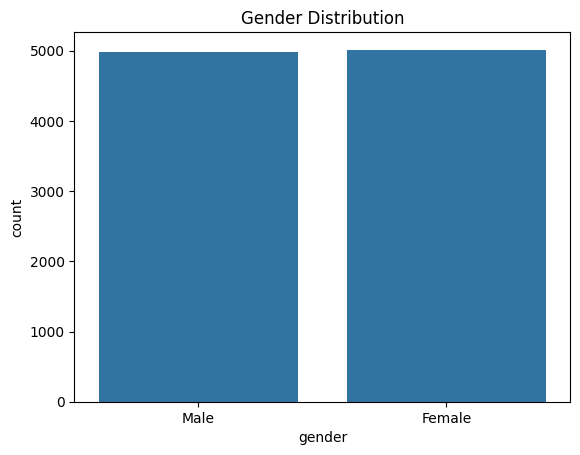

In [12]:
sns.countplot(x="gender", data=df)
plt.title("Gender Distribution")
plt.show()

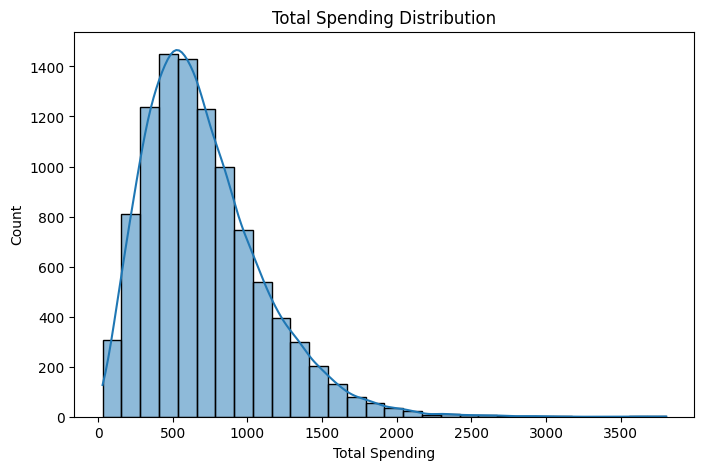

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df["total_spending"], bins=30, kde=True)
plt.title("Total Spending Distribution")
plt.xlabel("Total Spending")
plt.show()

Removing customer id

In [14]:
df_model = df.drop("customer_id", axis=1)

Gender (numerical conversion)


In [15]:
df_model["gender"] = df_model["gender"].map({
    "Male": 0,
    "Female": 1
})

In [16]:
df_model.head()

,age,gender,annual_income,total_spending,purchase_frequency,avg_order_value,website_visits,discount_usage,days_since_last_purchase,avg_rating,membership_years
0,56,0,39366,290.74,11,41.15,31,5,53,2.9,1.5
1,46,1,51571,175.30,7,26.88,25,4,41,4.3,1.5
2,32,1,33865,1422.43,11,84.64,32,5,27,3.5,2.8
3,60,1,47834,322.80,5,56.95,23,2,10,3.5,4.5
4,25,1,56197,752.09,7,67.55,21,1,49,3.3,1.4


In [17]:
X = df_model.copy()

In [18]:
X.shape

(10000, 11)

Feature Scaling

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [20]:
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled.head()

,age,gender,annual_income,total_spending,purchase_frequency,avg_order_value,website_visits,discount_usage,days_since_last_purchase,avg_rating,membership_years
0,1.383618,-1.003005,-1.197725,-1.051209,0.722420,-1.361533,0.785134,0.846822,0.550952,-1.412673,-0.423739
1,0.569629,0.997004,-0.636232,-1.342937,-0.707478,-1.938382,-0.395726,0.340168,0.194574,0.800730,-0.423739
2,-0.569955,0.997004,-1.450800,1.808677,0.722420,0.396503,0.981944,0.846822,-0.221201,-0.464072,0.131693
3,1.709213,0.997004,-0.808154,-0.970191,-1.422426,-0.722835,-0.789346,-0.673141,-0.726071,-0.464072,0.858027
4,-1.139747,0.997004,-0.423412,0.114665,-0.707478,-0.294342,-1.182966,-1.179795,0.432159,-0.780272,-0.466465


ELBOW METHOD

In [21]:
from sklearn.cluster import KMeans

In [22]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

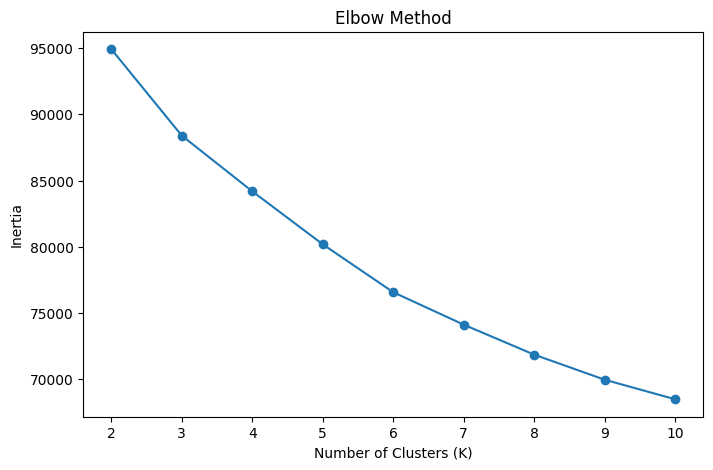

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), inertia, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

SILHOUTE SCORE

In [25]:
from sklearn.metrics import silhouette_score

In [26]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

In [27]:
for k, score in zip(range(2, 11), silhouette_scores):
    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.1303
K = 3, Silhouette Score = 0.1005
K = 4, Silhouette Score = 0.0921
K = 5, Silhouette Score = 0.0934
K = 6, Silhouette Score = 0.0950
K = 7, Silhouette Score = 0.0878
K = 8, Silhouette Score = 0.0861
K = 9, Silhouette Score = 0.0847
K = 10, Silhouette Score = 0.0841


In [29]:
best_k = 2

In [30]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

In [31]:
df["Cluster"] = clusters

In [32]:
df["Cluster"].value_counts().sort_index()

,count
Cluster,
0,4163
1,5837


In [33]:
cluster_profile = df.groupby("Cluster").mean(numeric_only=True)

cluster_profile

,customer_id,age,annual_income,total_spending,purchase_frequency,avg_order_value,website_visits,discount_usage,days_since_last_purchase,avg_rating,membership_years
Cluster,,,,,,,,,,,
0,14987.595724,39.075186,65350.966370,1009.710735,11.190247,81.791264,30.076387,4.664184,35.975979,3.781888,2.465818
1,15009.703444,38.949803,65435.964023,490.616807,7.402090,69.867528,24.824225,2.376049,33.358746,3.801833,2.510279


In [34]:
cluster_profile = df.drop("customer_id", axis=1).groupby("Cluster").mean(numeric_only=True)

cluster_profile

,age,annual_income,total_spending,purchase_frequency,avg_order_value,website_visits,discount_usage,days_since_last_purchase,avg_rating,membership_years
Cluster,,,,,,,,,,
0,39.075186,65350.966370,1009.710735,11.190247,81.791264,30.076387,4.664184,35.975979,3.781888,2.465818
1,38.949803,65435.964023,490.616807,7.402090,69.867528,24.824225,2.376049,33.358746,3.801833,2.510279


In [35]:
cluster_profile[
    [
        "age",
        "annual_income",
        "total_spending",
        "purchase_frequency",
        "avg_order_value",
        "website_visits",
        "discount_usage",
        "days_since_last_purchase",
        "avg_rating",
        "membership_years"
    ]
]

,age,annual_income,total_spending,purchase_frequency,avg_order_value,website_visits,discount_usage,days_since_last_purchase,avg_rating,membership_years
Cluster,,,,,,,,,,
0,39.075186,65350.966370,1009.710735,11.190247,81.791264,30.076387,4.664184,35.975979,3.781888,2.465818
1,38.949803,65435.964023,490.616807,7.402090,69.867528,24.824225,2.376049,33.358746,3.801833,2.510279


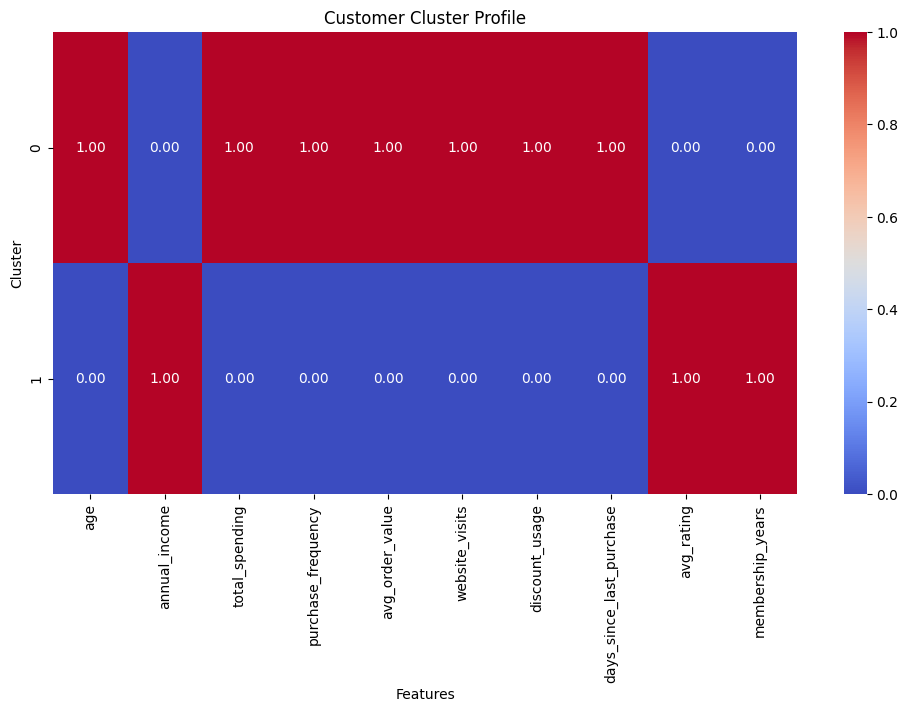

In [36]:
profile_scaled = cluster_profile.copy()

profile_scaled = (
    profile_scaled - profile_scaled.min()
) / (
    profile_scaled.max() - profile_scaled.min()
)

plt.figure(figsize=(12, 6))

sns.heatmap(
    profile_scaled,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Customer Cluster Profile")
plt.xlabel("Features")
plt.ylabel("Cluster")

plt.show()

In [37]:
cluster_profile.round(2)

,age,annual_income,total_spending,purchase_frequency,avg_order_value,website_visits,discount_usage,days_since_last_purchase,avg_rating,membership_years
Cluster,,,,,,,,,,
0,39.08,65350.97,1009.71,11.19,81.79,30.08,4.66,35.98,3.78,2.47
1,38.95,65435.96,490.62,7.40,69.87,24.82,2.38,33.36,3.80,2.51


In [38]:
cluster_profile.round(2).T


Cluster,0,1
age,39.08,38.95
annual_income,65350.97,65435.96
total_spending,1009.71,490.62
purchase_frequency,11.19,7.40
avg_order_value,81.79,69.87
website_visits,30.08,24.82
discount_usage,4.66,2.38
days_since_last_purchase,35.98,33.36
avg_rating,3.78,3.80
membership_years,2.47,2.51


pca

In [39]:
from sklearn.decomposition import PCA

In [40]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [41]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = clusters

pca_df.head()

,PC1,PC2,Cluster
0,0.292729,-2.141303,0
1,-1.470463,-1.866730,1
2,2.255255,0.436513,0
3,-2.044517,-0.199356,1
4,-1.386985,0.642498,1


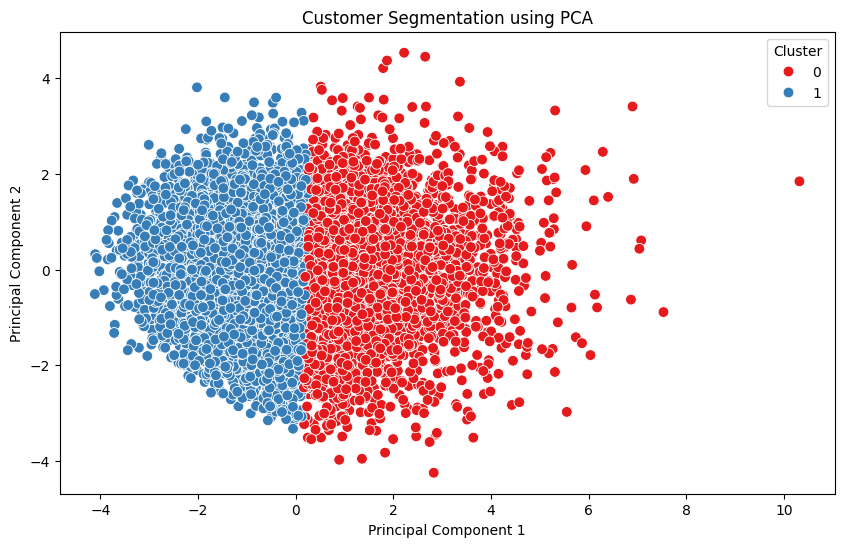

In [42]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1",
    s=60
)

plt.title("Customer Segmentation using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")

plt.show()

In [43]:
print("PC1 Variance:", round(pca.explained_variance_ratio_[0] * 100, 2), "%")
print("PC2 Variance:", round(pca.explained_variance_ratio_[1] * 100, 2), "%")

print(
    "Total Variance Explained:",
    round(pca.explained_variance_ratio_.sum() * 100, 2),
    "%"
)

PC1 Variance: 21.89 %
PC2 Variance: 11.84 %
Total Variance Explained: 33.72 %


In [44]:
cluster_counts = df["Cluster"].value_counts().sort_index()

print(cluster_counts)

Cluster
0    4163
1    5837
Name: count, dtype: int64


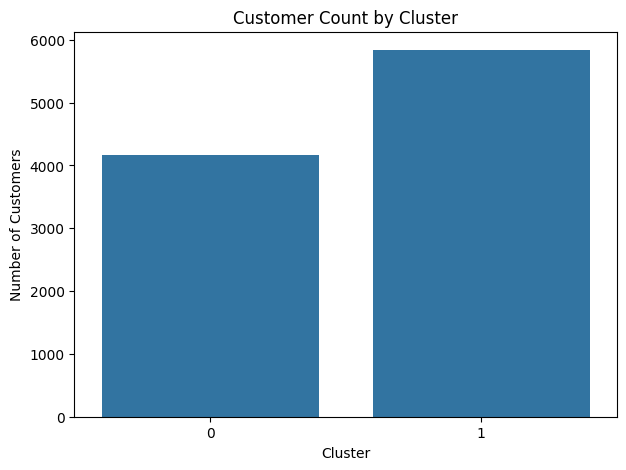

In [45]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values
)

plt.title("Customer Count by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.show()

In [46]:
cluster_percentage = (
    df["Cluster"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

print(cluster_percentage.round(2))

Cluster
0    41.63
1    58.37
Name: proportion, dtype: float64


In [47]:
final_profile = df.drop(
    "customer_id",
    axis=1
).groupby("Cluster").mean(numeric_only=True).round(2)

final_profile

,age,annual_income,total_spending,purchase_frequency,avg_order_value,website_visits,discount_usage,days_since_last_purchase,avg_rating,membership_years
Cluster,,,,,,,,,,
0,39.08,65350.97,1009.71,11.19,81.79,30.08,4.66,35.98,3.78,2.47
1,38.95,65435.96,490.62,7.40,69.87,24.82,2.38,33.36,3.80,2.51
